# 1. Data Ingestion
#### We ingest the data, study the table counts and NULLs in the tables and then establish a relevant ERD for the 8 tables.

In [2]:
'''
Sampling and Export Script

Loads each Dunnhumby CSV table into pandas DataFrames using the same filenames
as your ingestion code, then exports the top 1,000 rows from each table
for schema inspection.
'''

import os
import pandas as pd

# ----------------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------------
# Path to your data directory containing raw CSVs
DATA_DIR = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/Data"
# Directory to hold exported samples (creates if missing)
SAMPLE_DIR = os.path.join(os.path.dirname(DATA_DIR), 'samples')
os.makedirs(SAMPLE_DIR, exist_ok=True)

# ----------------------------------------------------------------------------
# Load Tables 
# ----------------------------------------------------------------------------
transactions_df     = pd.read_csv(os.path.join(DATA_DIR, 'transaction_data.csv'))
product_df          = pd.read_csv(os.path.join(DATA_DIR, 'product.csv'))
coupon_df           = pd.read_csv(os.path.join(DATA_DIR, 'coupon.csv'))
hh_demographic_df   = pd.read_csv(os.path.join(DATA_DIR, 'hh_demographic.csv'))
campaign_table_df   = pd.read_csv(os.path.join(DATA_DIR, 'campaign_table.csv'))
causal_data_df      = pd.read_csv(os.path.join(DATA_DIR, 'causal_data.csv'))
campaign_desc_df    = pd.read_csv(os.path.join(DATA_DIR, 'campaign_desc.csv'))
coupon_redempt_df   = pd.read_csv(os.path.join(DATA_DIR, 'coupon_redempt.csv'))



In [3]:
# ----------------------------------------------------------------------------
# Sampling and Export
# ----------------------------------------------------------------------------
SAMPLE_SIZE = 1000

tables = {
    'transactions': transactions_df,
    'product': product_df,
    'coupon': coupon_df,
    'hh_demographic': hh_demographic_df,
    'campaign_table': campaign_table_df,
    'causal_data': causal_data_df,
    'campaign_desc': campaign_desc_df,
    'coupon_redempt': coupon_redempt_df,
}

for name, df in tables.items():
    # Select top rows (or full DF if smaller)
    sample_df = df.head(SAMPLE_SIZE) if len(df) >= SAMPLE_SIZE else df.copy()
    out_path = os.path.join(SAMPLE_DIR, f"{name}_sample.csv")
    sample_df.to_csv(out_path, index=False)
    print(f"Exported {sample_df.shape[0]} rows to {out_path}")


Exported 1000 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\transactions_sample.csv
Exported 1000 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\product_sample.csv
Exported 1000 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\coupon_sample.csv
Exported 801 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\hh_demographic_sample.csv
Exported 1000 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\campaign_table_sample.csv
Exported 1000 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\causal_data_sample.csv
Exported 30 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\campaign_desc_sample.csv
Exported 1000 rows to C:/Users/sachi/Desktop/MSc Data Science/DSML\samples\coupon_redempt_sample.csv


### 1.1 Table counts and NULLs

In [5]:
# -------------------------------------------------------------------------------------------
# Profiling Function - To iteratively provide counts and NULLs for each table with data types
# -------------------------------------------------------------------------------------------
def profile(df: pd.DataFrame, name: str):
    """
    Print table-level diagnostics for a DataFrame.
    """
    print(f"\n=== Profile: {name} ===")
    # Total rows and columns
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

    # Null counts per column
    null_counts = df.isna().sum()
    if null_counts.any():
        print("Null values per column:")
        print(null_counts[null_counts > 0].sort_values(ascending=False))
    else:
        print("No null values detected.")

    # Unique-value counts per column
    print("Unique-value count per column:")
    unique_counts = df.nunique(dropna=False)
    print(unique_counts.sort_values(ascending=False))

    # Data types
    print("Data types:")
    print(df.dtypes)

# ----------------------------------------------------------------------------
# Main execution of profiling function
# ----------------------------------------------------------------------------
if __name__ == '__main__':
    tables = [
        ('transactions', transactions_df),
        ('product', product_df),
        ('coupon', coupon_df),
        ('hh_demographic', hh_demographic_df),
        ('campaign_table', campaign_table_df),
        ('causal_data', causal_data_df),
        ('campaign_desc', campaign_desc_df),
        ('coupon_redempt', coupon_redempt_df),
    ]
    for name, df in tables:
        profile(df, name)


=== Profile: transactions ===
Shape: 2595732 rows × 12 columns
No null values detected.
Unique-value count per column:
BASKET_ID            276484
PRODUCT_ID            92339
QUANTITY              11746
SALES_VALUE            5502
household_key          2500
RETAIL_DISC            2414
TRANS_TIME             1440
DAY                     711
STORE_ID                582
COUPON_DISC             415
WEEK_NO                 102
COUPON_MATCH_DISC        80
dtype: int64
Data types:
household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
TRANS_TIME             int64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object

=== Profile: product ===
Shape: 92353 rows × 7 columns
No null values detected.
Unique-value count per column:
PRODUCT_ID              92353
MANUFACTURER   

### 1.2 Move table to SQL dB

In [7]:
# Initialize SQLite and Load Raw CSVs into Tables
import os
import pandas as pd
from sqlalchemy import create_engine

# === Configuration of the directory ===
DATA_DIR = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/Data"
DB_PATH = os.path.join(DATA_DIR, "dunnhumby.db")
engine = create_engine(f"sqlite:///{DB_PATH}")

# === Table Mapping (CSV filename → SQLite table name) ===
table_files = {
    "transactions": "transaction_data.csv",
    "product": "product.csv",
    "coupon": "coupon.csv",
    "hh_demographic": "hh_demographic.csv",
    "campaign_table": "campaign_table.csv",
    "causal_data": "causal_data.csv",
    "campaign_desc": "campaign_desc.csv",
    "coupon_redempt": "coupon_redempt.csv"
}

# === Load and write each table to SQLite ===
for table, csv_file in table_files.items():
    file_path = os.path.join(DATA_DIR, csv_file)
    df = pd.read_csv(file_path)
    df.to_sql(table, con=engine, if_exists='replace', index=False)
    print(f"✅ Loaded '{table}' ({df.shape[0]} rows)")


✅ Loaded 'transactions' (2595732 rows)
✅ Loaded 'product' (92353 rows)
✅ Loaded 'coupon' (124548 rows)
✅ Loaded 'hh_demographic' (801 rows)
✅ Loaded 'campaign_table' (7208 rows)
✅ Loaded 'causal_data' (36786524 rows)
✅ Loaded 'campaign_desc' (30 rows)
✅ Loaded 'coupon_redempt' (2318 rows)


### 1.3 Entity relationships 

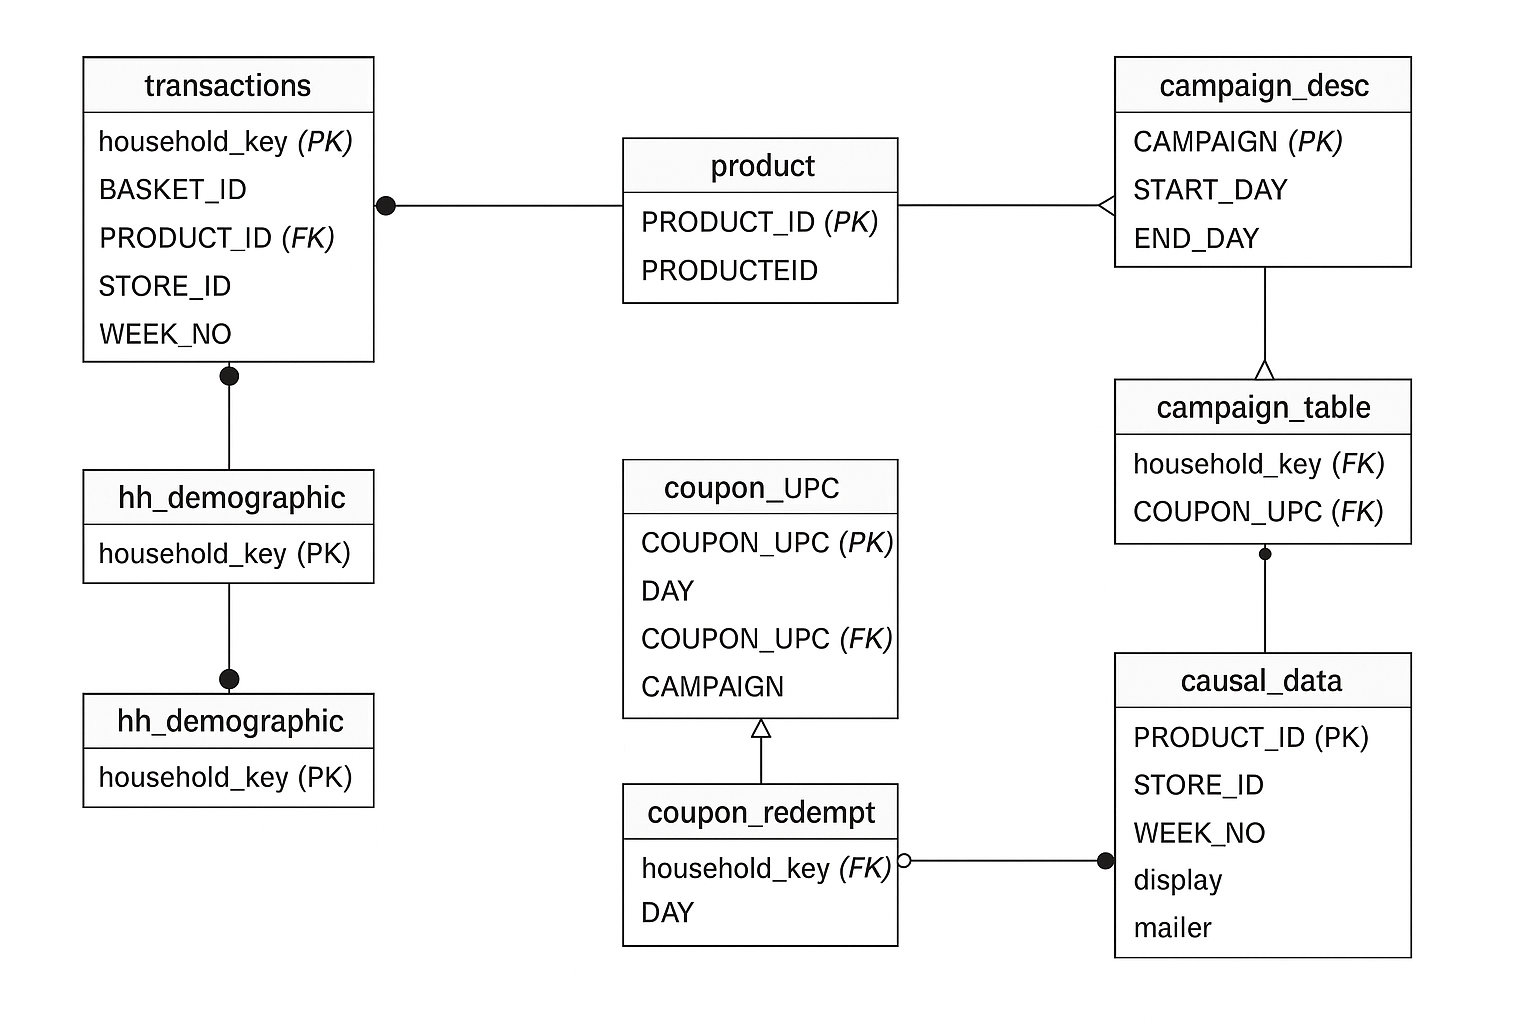

In [59]:
from IPython.display import Image, display

image_path = "C:/Users/sachi/Downloads/DSML - ERD.png"
display(Image(filename=image_path))


# 2. Data Wrangling & EDA

### 2.1 Create transaction_product table (SQL)

In [11]:
from sqlalchemy import text

# First: Drop table if exists
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS transaction_product;"))

# Then: Create the new transaction_product table
create_txn_product_sql = """
CREATE TABLE transaction_product AS
SELECT
    t.household_key,
    t.BASKET_ID,
    t.PRODUCT_ID,
    t.DAY,
    t.WEEK_NO,
    t.QUANTITY,
    t.SALES_VALUE,
    t.RETAIL_DISC,
    t.TRANS_TIME,
    p.DEPARTMENT,
    p.BRAND
FROM transactions t
LEFT JOIN product p
    ON t.PRODUCT_ID = p.PRODUCT_ID;
"""

with engine.begin() as conn:
    conn.execute(text(create_txn_product_sql))

print("✅ Successfully created 'transaction_product' table.")


✅ Successfully created 'transaction_product' table.


In [12]:
# Cell: Compare row count between original and joined table

query = """
SELECT 
    (SELECT COUNT(*) FROM transactions) AS transaction_rows,
    (SELECT COUNT(*) FROM transaction_product) AS transaction_product_rows;
"""

pd.read_sql(query, engine)


,transaction_rows,transaction_product_rows
0,2595732,2595732


### 2.2 Additional transaction metrics
#### Adding Average transaction value (ATV), Average basket size (ABS), Average price point (APP), Number of visits for all households and repeat purchasing households

In [14]:
from sqlalchemy import text

# Drop the table if it exists
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS weekly_transaction_metrics;"))

# Create the weekly_transaction_metrics table
weekly_metrics_sql = """
CREATE TABLE weekly_transaction_metrics AS
WITH basket_summary AS (
    SELECT
        WEEK_NO,
        BASKET_ID,
        household_key,
        COUNT(DISTINCT PRODUCT_ID) AS basket_size,
        SUM(SALES_VALUE) AS basket_value,
        SUM(SALES_VALUE) * 1.0 / SUM(QUANTITY) AS avg_price_point
    FROM transaction_product
    GROUP BY WEEK_NO, BASKET_ID, household_key
),
repeat_baskets AS (
    SELECT
        WEEK_NO,
        household_key,
        COUNT(DISTINCT BASKET_ID) AS num_repeat_baskets,
        SUM(QUANTITY) AS repeat_qty
    FROM transaction_product
    GROUP BY WEEK_NO, household_key
    HAVING COUNT(DISTINCT BASKET_ID) > 1
),
repeat_basket_summary AS (
    SELECT
        bs.WEEK_NO,
        bs.BASKET_ID,
        bs.household_key,
        bs.basket_value,
        bs.avg_price_point,
        bs.basket_size
    FROM basket_summary bs
    INNER JOIN repeat_baskets rb
        ON bs.WEEK_NO = rb.WEEK_NO AND bs.household_key = rb.household_key
)
SELECT
    bs.WEEK_NO,
    COUNT(DISTINCT bs.household_key) AS unique_households,
    COUNT(DISTINCT bs.BASKET_ID) AS unique_transactions,
    ROUND(AVG(bs.basket_value), 2) AS avg_transaction_value,
    ROUND(AVG(bs.avg_price_point), 2) AS avg_price_point,
    ROUND(AVG(bs.basket_size), 2) AS avg_basket_size,
    COUNT(DISTINCT rb.household_key) AS repeat_households,
    COUNT(DISTINCT CASE WHEN rb.household_key IS NOT NULL THEN bs.BASKET_ID END) AS repeat_transactions,
    ROUND(AVG(rbs.basket_value), 2) AS repeat_avg_transaction_value,
    ROUND(AVG(rbs.avg_price_point), 2) AS repeat_avg_price_point,
    ROUND(AVG(rbs.basket_size), 2) AS repeat_avg_basket_size,
    COUNT(DISTINCT bs.household_key || bs.BASKET_ID) AS total_visits,
    COUNT(DISTINCT CASE WHEN rb.household_key IS NOT NULL THEN bs.household_key || bs.BASKET_ID END) AS repeat_visits
FROM basket_summary bs
LEFT JOIN repeat_baskets rb
  ON bs.WEEK_NO = rb.WEEK_NO AND bs.household_key = rb.household_key
LEFT JOIN repeat_basket_summary rbs
  ON bs.WEEK_NO = rbs.WEEK_NO AND bs.BASKET_ID = rbs.BASKET_ID
GROUP BY bs.WEEK_NO
ORDER BY bs.WEEK_NO;
"""

# Execute the SQL
with engine.begin() as conn:
    conn.execute(text(weekly_metrics_sql))

print("✅ Created 'weekly_transaction_metrics' table.")


✅ Created 'weekly_transaction_metrics' table.


In [15]:
pd.read_sql("SELECT * FROM weekly_transaction_metrics LIMIT 15;", engine)


,WEEK_NO,unique_households,unique_transactions,avg_transaction_value,avg_price_point,avg_basket_size,repeat_households,repeat_transactions,repeat_avg_transaction_value,repeat_avg_price_point,repeat_avg_basket_size,total_visits,repeat_visits
0,1,88,142,36.70,3.15,13.25,32,86,33.26,3.66,12.09,142,86
1,2,175,324,33.40,3.32,11.34,72,221,26.52,2.70,9.21,324,221
2,3,228,482,28.00,2.49,9.96,96,350,24.34,2.43,8.74,482,350
3,4,270,545,29.30,2.55,9.87,127,402,26.82,2.57,8.85,545,402
4,5,370,757,26.60,2.54,9.47,164,551,20.59,2.54,7.17,757,551
5,6,433,861,28.95,2.52,10.33,195,623,25.96,2.57,8.86,861,623
6,7,491,999,28.10,2.89,8.99,251,759,24.83,2.91,7.80,999,759
7,8,530,1086,29.28,2.71,9.60,254,810,24.61,2.74,8.00,1086,810
8,9,622,1212,25.78,2.34,8.73,282,872,22.72,2.24,7.62,1212,872
9,10,708,1553,27.68,2.57,8.72,366,1211,24.68,2.58,7.61,1553,1211


In [16]:
# Export weekly_transaction_metrics to CSV
output_path = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/weekly_transaction_metrics.csv"

df_weekly = pd.read_sql("SELECT * FROM weekly_transaction_metrics", engine)
df_weekly.to_csv(output_path, index=False)

print(f"✅ Exported to {output_path}")


✅ Exported to C:/Users/sachi/Desktop/MSc Data Science/DSML/weekly_transaction_metrics.csv


### 2.3 Add Visit Latency
#### What is the average days between subsequent for repeat customers?

In [18]:
from sqlalchemy import text

# Drop if exists
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS household_visit_latency;"))

# Create visit latency table
visit_latency_sql = """
CREATE TABLE household_visit_latency AS
WITH visit_days AS (
    SELECT DISTINCT household_key, DAY
    FROM transaction_product
),
visit_stats AS (
    SELECT
        household_key,
        MIN(DAY) AS first_visit,
        MAX(DAY) AS last_visit,
        COUNT(DISTINCT DAY) AS num_visits
    FROM visit_days
    GROUP BY household_key
    HAVING num_visits > 1
)
SELECT
    household_key,
    first_visit,
    last_visit,
    num_visits,
    (last_visit - first_visit) AS total_span,
    ROUND(1.0 * (last_visit - first_visit) / (num_visits - 1), 2) AS avg_days_between_visits
FROM visit_stats;
"""

with engine.begin() as conn:
    conn.execute(text(visit_latency_sql))

print("✅ Created 'household_visit_latency' table.")


✅ Created 'household_visit_latency' table.


In [19]:
# Export household_visit_latency to CSV
output_path = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/household_visit_latency.csv"

df_latency = pd.read_sql("SELECT * FROM household_visit_latency", engine)
df_latency.to_csv(output_path, index=False)

print(f"✅ Exported to {output_path}")

✅ Exported to C:/Users/sachi/Desktop/MSc Data Science/DSML/household_visit_latency.csv


### 2.4 Campaign reponses table 
#### Estimate Map campaign targeting and coupon usage data to households

In [21]:
from sqlalchemy import text

# Drop if exists
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS campaign_target_summary;"))

# Create campaign_target_summary table
campaign_target_sql = """
CREATE TABLE campaign_target_summary AS
WITH campaigns_per_household AS (
    SELECT household_key, COUNT(DISTINCT CAMPAIGN) AS campaigns_received
    FROM campaign_table
    GROUP BY household_key
),
coupons_received AS (
    SELECT ct.household_key, COUNT(DISTINCT c.COUPON_UPC) AS total_coupons
    FROM campaign_table ct
    JOIN coupon c ON ct.CAMPAIGN = c.CAMPAIGN
    GROUP BY ct.household_key
),
coupon_hits AS (
    SELECT cr.household_key, 
           COUNT(DISTINCT cr.COUPON_UPC) AS coupons_redeemed,
           COUNT(DISTINCT cr.CAMPAIGN) AS campaigns_responded
    FROM coupon_redempt cr
    GROUP BY cr.household_key
)
SELECT
    cph.household_key,
    cph.campaigns_received,
    COALESCE(crv.total_coupons, 0) AS total_coupons_received,
    COALESCE(hit.coupons_redeemed, 0) AS coupons_redeemed,
    COALESCE(hit.campaigns_responded, 0) AS campaigns_responded
FROM campaigns_per_household cph
LEFT JOIN coupons_received crv ON cph.household_key = crv.household_key
LEFT JOIN coupon_hits hit ON cph.household_key = hit.household_key;
"""

with engine.begin() as conn:
    conn.execute(text(campaign_target_sql))

print("✅ Created 'campaign_target_summary' table.")

✅ Created 'campaign_target_summary' table.


In [22]:
# Export to CSV
output_path = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/campaign_target_summary.csv"
df_export = pd.read_sql("SELECT * FROM campaign_target_summary", engine)
df_export.to_csv(output_path, index=False)
print(f"📁 Exported to {output_path}")

📁 Exported to C:/Users/sachi/Desktop/MSc Data Science/DSML/campaign_target_summary.csv


### 2.5 Top coupon redeemed products
#### Which products drive coupon usage?

In [24]:
# Export comparison of coupon redemptions by department
compare_coupon_sales_sql = """
WITH all_sales AS (
    SELECT 
        p.DEPARTMENT,
        SUM(t.QUANTITY) AS total_qty
    FROM transaction_product t
    JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
    GROUP BY p.DEPARTMENT
),
coupon_sales AS (
    SELECT 
        p.DEPARTMENT,
        SUM(t.QUANTITY) AS coupon_qty
    FROM coupon_redempt cr
    JOIN coupon c ON cr.COUPON_UPC = c.COUPON_UPC
    JOIN transaction_product t ON c.PRODUCT_ID = t.PRODUCT_ID
                                 AND cr.DAY = t.DAY
                                 AND cr.household_key = t.household_key
    JOIN product p ON t.PRODUCT_ID = p.PRODUCT_ID
    GROUP BY p.DEPARTMENT
)
SELECT 
    a.DEPARTMENT,
    a.total_qty,
    COALESCE(c.coupon_qty, 0) AS coupon_qty,
    ROUND(100.0 * COALESCE(c.coupon_qty, 0) / a.total_qty, 2) AS coupon_pct
FROM all_sales a
LEFT JOIN coupon_sales c ON a.DEPARTMENT = c.DEPARTMENT
ORDER BY coupon_qty DESC;
"""

df_coupon_comparison = pd.read_sql(compare_coupon_sales_sql, engine)
output_path_3 = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/coupon_redemption_by_department.csv"
df_coupon_comparison.to_csv(output_path_3, index=False)
print(f"📁 Exported coupon redemption analysis to {output_path_3}")

📁 Exported coupon redemption analysis to C:/Users/sachi/Desktop/MSc Data Science/DSML/coupon_redemption_by_department.csv


In [25]:
df_coupon_comparison

,DEPARTMENT,total_qty,coupon_qty,coupon_pct
0,GROCERY,2194762,6239,0.28
1,PRODUCE,319993,718,0.22
2,DRUG GM,353844,602,0.17
3,MEAT-PCKGD,148148,373,0.25
4,MEAT,119113,333,0.28
5,SEAFOOD-PCKGD,14003,96,0.69
6,NUTRITION,43253,60,0.14
7,COSMETICS,7984,16,0.20
8,DELI,67026,12,0.02
9,FLORAL,5586,10,0.18


### 2.6 Add department composition 
#### What are the top departments and their % purchase share for each household?

In [99]:
# Create household-level department composition
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS household_department_share;"))

department_sql = """
CREATE TABLE household_department_share AS
WITH dept_sales AS (
    SELECT tp.household_key, p.DEPARTMENT, SUM(tp.SALES_VALUE) AS dept_sales
    FROM transaction_product tp
    JOIN product p ON tp.PRODUCT_ID = p.PRODUCT_ID
    GROUP BY tp.household_key, p.DEPARTMENT
),
total_sales AS (
    SELECT household_key, SUM(SALES_VALUE) AS total_sales
    FROM transaction_product
    GROUP BY household_key
)
SELECT 
    d.household_key,
    d.DEPARTMENT,
    d.dept_sales,
    t.total_sales,
    ROUND(100.0 * d.dept_sales / t.total_sales, 2) AS pct_contribution
FROM dept_sales d
JOIN total_sales t ON d.household_key = t.household_key;
"""

with engine.begin() as conn:
    conn.execute(text(department_sql))

# Pivot department share wide for household_key
query = "SELECT * FROM household_department_share"
df_dept_wide = pd.read_sql(query, engine)
df_dept_pivot = df_dept_wide.pivot(index='household_key', columns='DEPARTMENT', values='pct_contribution').fillna(0).reset_index()

# Export pivoted table
output_path_5 = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/household_department_contribution_wide.csv"
df_dept_pivot.to_csv(output_path_5, index=False)
print(f"📁 Exported pivoted department contribution to {output_path_5}")

# Merge department composition into final summary
# Read existing summary and merge department-wise contribution
df_summary = pd.read_sql("SELECT * FROM household_behavior_summary", engine)
df_merged = pd.merge(df_summary, df_dept_pivot, on="household_key", how="left")

# Export final merged summary with department composition
output_path_final = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/household_behavior_summary_with_dept.csv"
df_merged.to_csv(output_path_final, index=False)
print(f"📁 Exported household-level summary WITH department composition to {output_path_final}")


📁 Exported pivoted department contribution to C:/Users/sachi/Desktop/MSc Data Science/DSML/household_department_contribution_wide.csv
📁 Exported household-level summary WITH department composition to C:/Users/sachi/Desktop/MSc Data Science/DSML/household_behavior_summary_with_dept.csv


In [101]:
df_merged

,household_key,AGE_DESC,INCOME_DESC,HOMEOWNER_DESC,MARITAL_STATUS_CODE,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,avg_transaction_value,avg_price_point,avg_basket_size,...,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL
0,1,65+,35-49K,Homeowner,A,2,None/Unknown,50.35,2.64,20.08,...,0.1,0.0,0.95,0.00,0.00,0.00,0.0,0.00,0.0,0.0
1,2,None,None,None,None,None,None,43.43,2.88,15.87,...,0.0,0.0,0.00,0.00,0.46,0.00,0.0,0.00,0.0,0.0
2,3,None,None,None,None,None,None,56.45,1.84,19.62,...,0.0,0.0,0.05,0.00,0.38,0.00,0.0,0.00,0.0,0.0
3,4,None,None,None,None,None,None,40.00,3.35,10.03,...,0.0,0.0,0.00,0.00,1.11,0.00,0.0,0.00,0.0,0.0
4,5,None,None,None,None,None,None,19.48,4.45,5.55,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,45-54,75-99K,Homeowner,A,3,1,68.88,2.42,23.63,...,0.0,0.0,0.00,1.60,0.14,0.28,0.0,0.00,0.0,0.0
2496,2497,45-54,35-49K,Unknown,U,1,None/Unknown,32.18,2.83,8.88,...,0.0,0.0,0.08,0.00,0.86,0.00,0.0,0.00,0.0,0.0
2497,2498,25-34,50-74K,Homeowner,U,2,None/Unknown,15.13,2.89,4.99,...,0.0,0.0,0.72,0.00,0.00,0.61,0.0,0.12,0.0,0.0
2498,2499,25-34,Under 15K,Unknown,U,3,1,37.71,2.69,12.96,...,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.15,0.0,0.0


### 2.7 Study Data representation

In [103]:
# Ensure the merged summary is reloaded
df_merged = pd.read_csv(r"C:/Users/sachi/Desktop/MSc Data Science/DSML/household_behavior_summary_with_dept.csv")

# Filter to include only households with complete demographic data
df_subset = df_merged.dropna(subset=[
    "AGE_DESC", "INCOME_DESC", "HOMEOWNER_DESC", 
    "MARITAL_STATUS_CODE", "HOUSEHOLD_SIZE_DESC", "KID_CATEGORY_DESC"
])

# Export to CSV
output_path_subset = r"C:/Users/sachi/Desktop/MSc Data Science/DSML/household_subset_for_modeling.csv"
df_subset.to_csv(output_path_subset, index=False)
print(f"✅ Exported filtered subset to {output_path_subset}")


✅ Exported filtered subset to C:/Users/sachi/Desktop/MSc Data Science/DSML/household_subset_for_modeling.csv


df_subset

### 2.8 EDA Summary

<Figure size 1400x800 with 0 Axes>

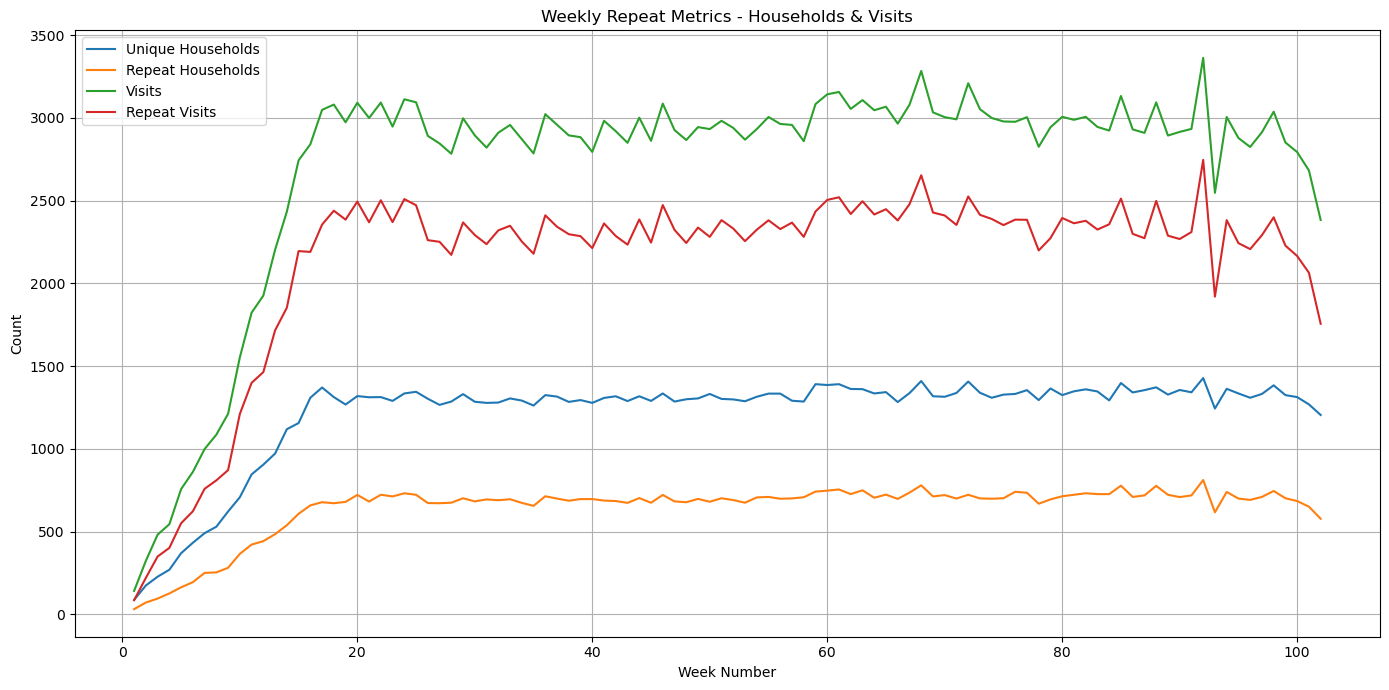

In [88]:
# Re-import plt if not already defined
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load weekly transaction metrics table
weekly_df = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/weekly_transaction_metrics.csv")

# Plot weekly transaction KPIs
plt.figure(figsize=(14, 8))
# ----------------------------
# EDA Plot 1: Weekly Repeat Metrics
# ----------------------------
weekly_df = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/weekly_transaction_metrics.csv")

plt.figure(figsize=(14, 7))
plt.plot(weekly_df["WEEK_NO"], weekly_df["unique_households"], label="Unique Households")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_households"], label="Repeat Households")
plt.plot(weekly_df["WEEK_NO"], weekly_df["unique_transactions"], label="Visits")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_transactions"], label="Repeat Visits")
plt.xlabel("Week Number")
plt.ylabel("Count")
plt.title("Weekly Repeat Metrics - Households & Visits")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


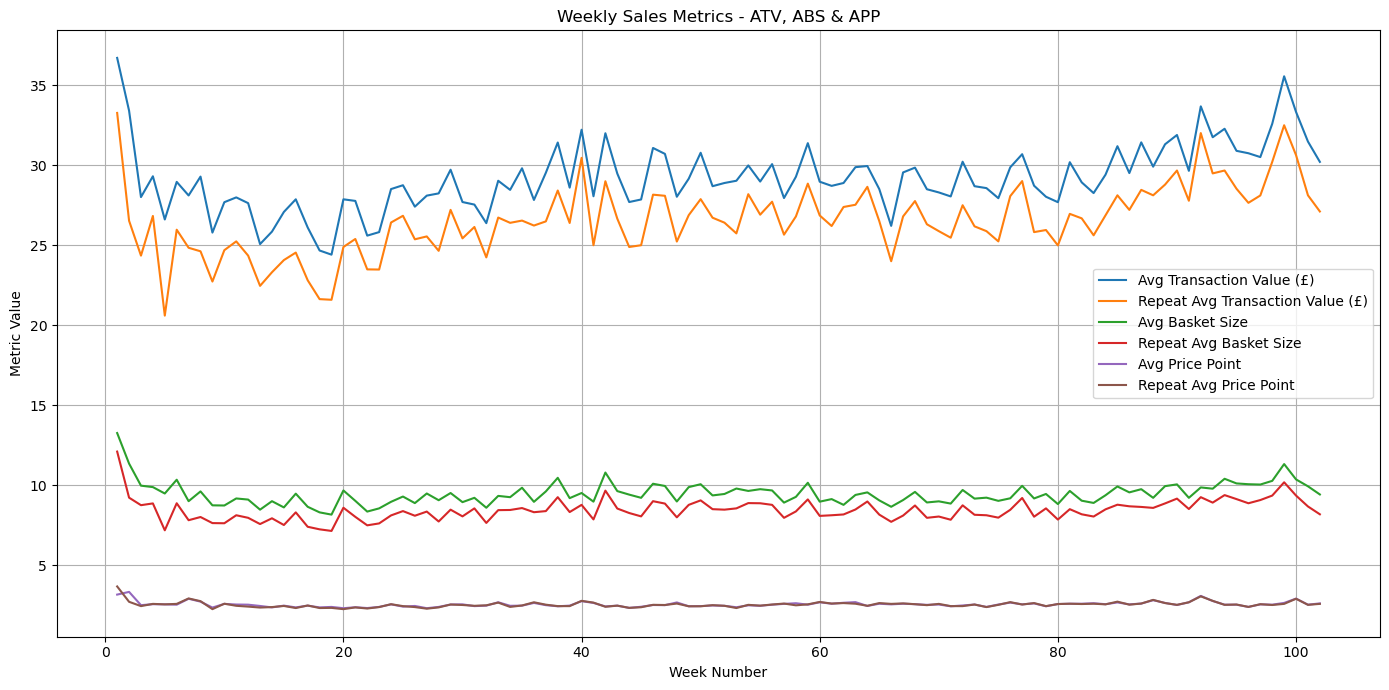

In [90]:
# ----------------------------
# EDA Plot 2: Weekly Sales Metrics
# ----------------------------
plt.figure(figsize=(14, 7))
plt.plot(weekly_df["WEEK_NO"], weekly_df["avg_transaction_value"], label="Avg Transaction Value (£)")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_avg_transaction_value"], label="Repeat Avg Transaction Value (£)")
plt.plot(weekly_df["WEEK_NO"], weekly_df["avg_basket_size"], label="Avg Basket Size")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_avg_basket_size"], label="Repeat Avg Basket Size")
plt.plot(weekly_df["WEEK_NO"], weekly_df["avg_price_point"], label="Avg Price Point")
plt.plot(weekly_df["WEEK_NO"], weekly_df["repeat_avg_price_point"], label="Repeat Avg Price Point")
plt.xlabel("Week Number")
plt.ylabel("Metric Value")
plt.title("Weekly Sales Metrics - ATV, ABS & APP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


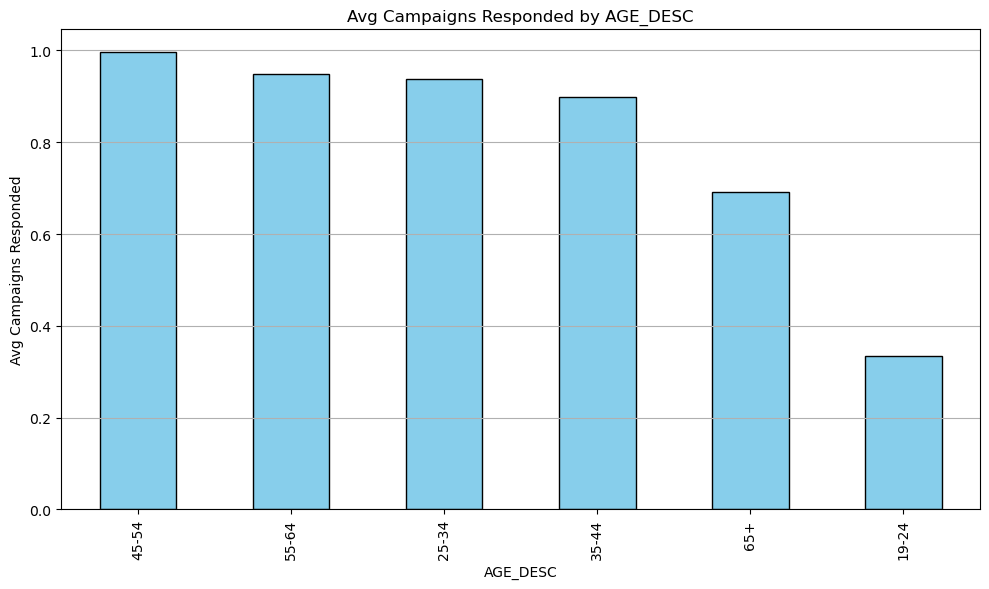

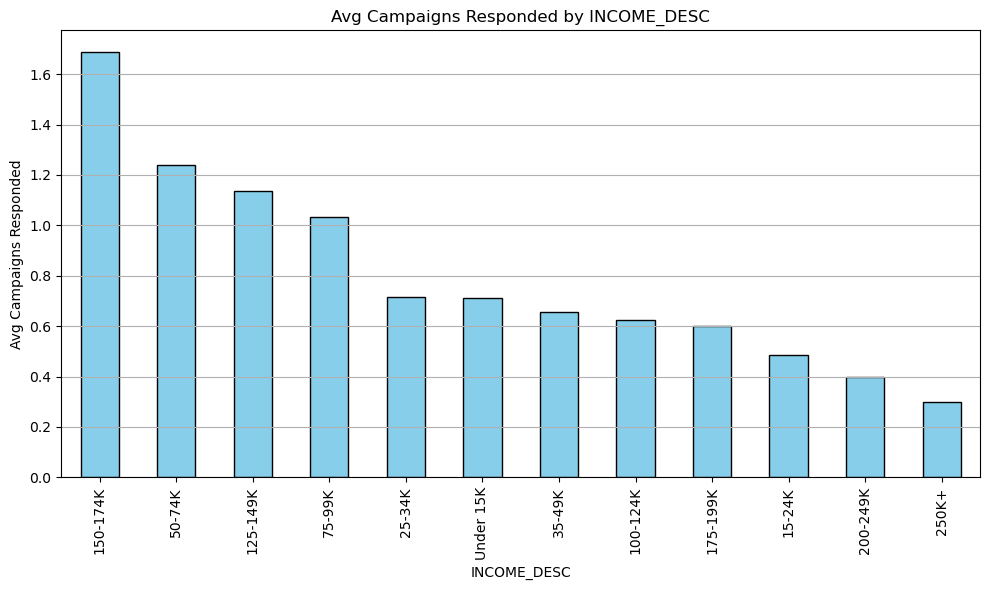

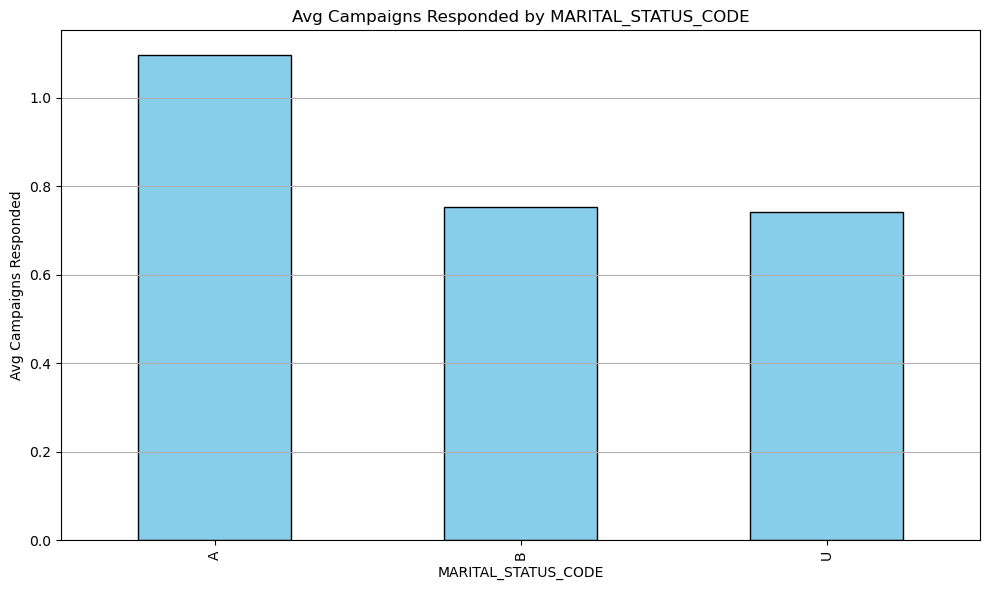

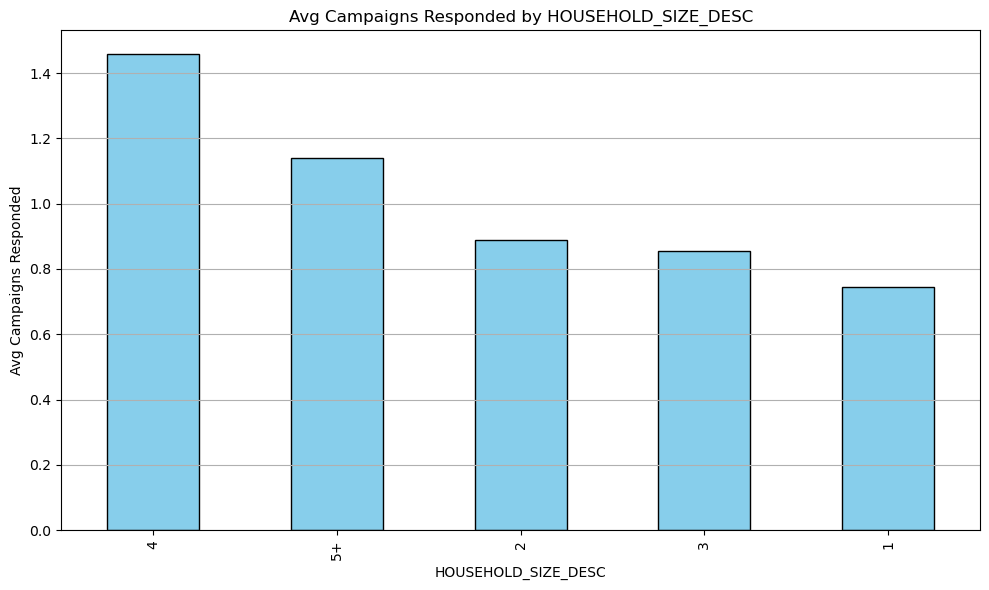

In [95]:
# ----------------------------
# EDA Plot 3: Campaign Responsiveness by Segment
# ----------------------------
campaign_df = df_subset.copy()

segment_cols = ["AGE_DESC", "INCOME_DESC", "MARITAL_STATUS_CODE", "HOUSEHOLD_SIZE_DESC"]
for col in segment_cols:
    plt.figure(figsize=(10, 6))
    campaign_group = campaign_df.groupby(col)["campaigns_responded"].mean().sort_values(ascending=False)
    campaign_group.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title(f"Avg Campaigns Responded by {col}")
    plt.ylabel("Avg Campaigns Responded")
    plt.xlabel(col)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


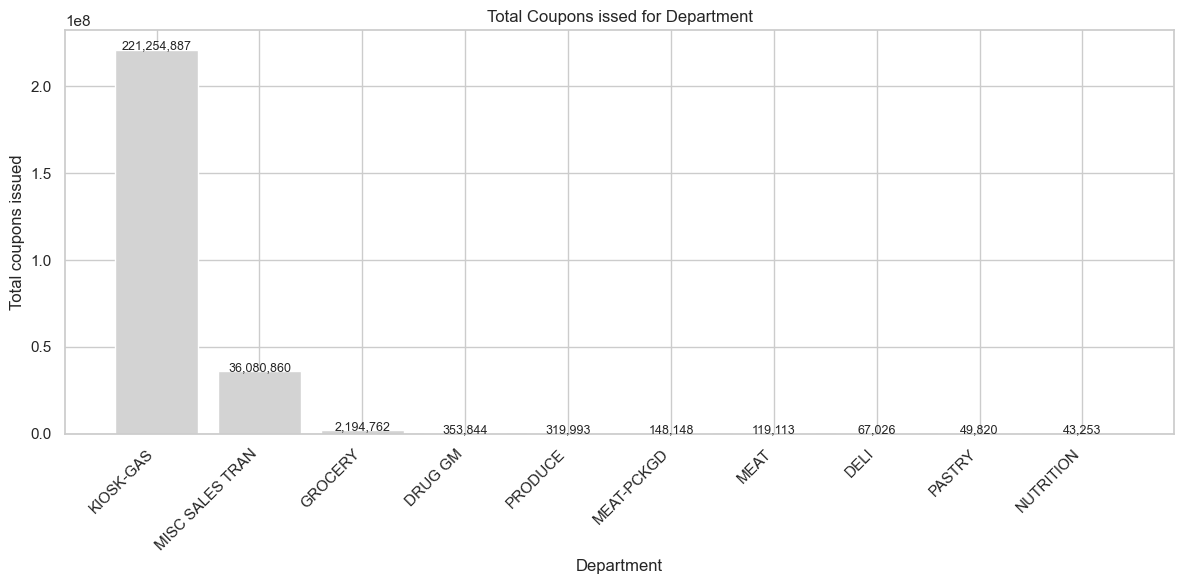

In [123]:
import matplotlib.pyplot as plt

# Sort top 10 by total_qty
top_depts = df_coupon_comparison.sort_values(by="total_qty", ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_depts["DEPARTMENT"], top_depts["total_qty"], color="lightgrey")

# Labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f"{int(bar.get_height()):,}", ha='center', fontsize=9)

plt.title("Total Coupons issed for Department")
plt.xlabel("Department")
plt.ylabel("Total coupons issued")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


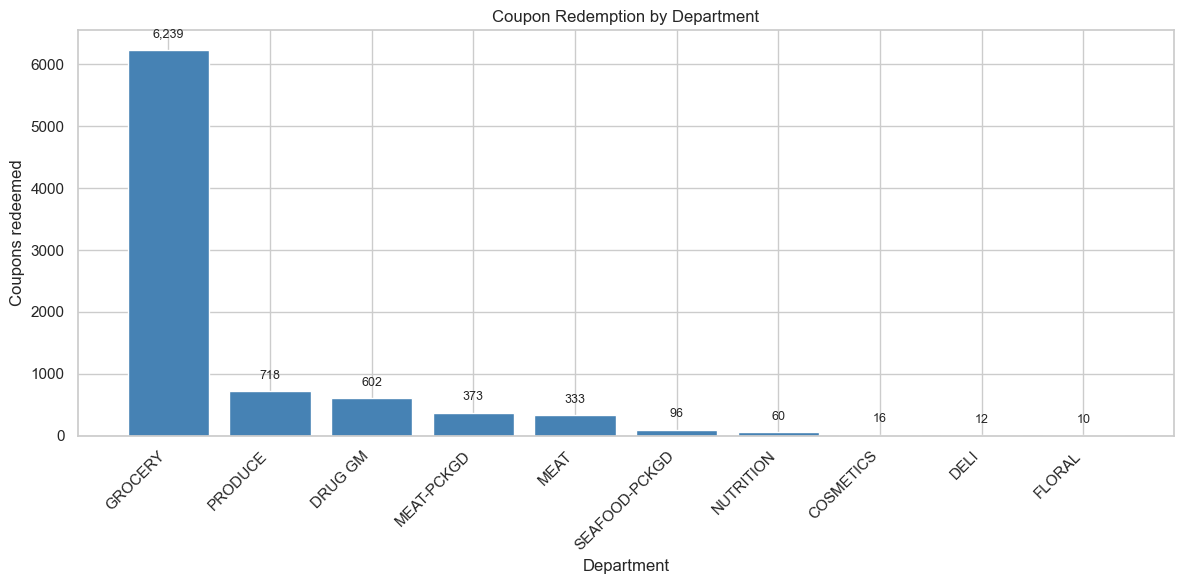

In [127]:
# Sort top 10 by coupon_qty
top_coupon = df_coupon_comparison.sort_values(by="coupon_qty", ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top_coupon["DEPARTMENT"], top_coupon["coupon_qty"], color="steelblue")

# Labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{int(bar.get_height()):,}", ha='center', fontsize=9)

plt.title("Coupon Redemption by Department")
plt.xlabel("Department")
plt.ylabel("Coupons redeemed")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 3. Feature importance
#### What are the top features causing variability in purchase behaviour?
##### We model the data with total sales as the dependent variable - Our objective is to get mutually exclusive segments which can be leveraged for customer targeting strategies

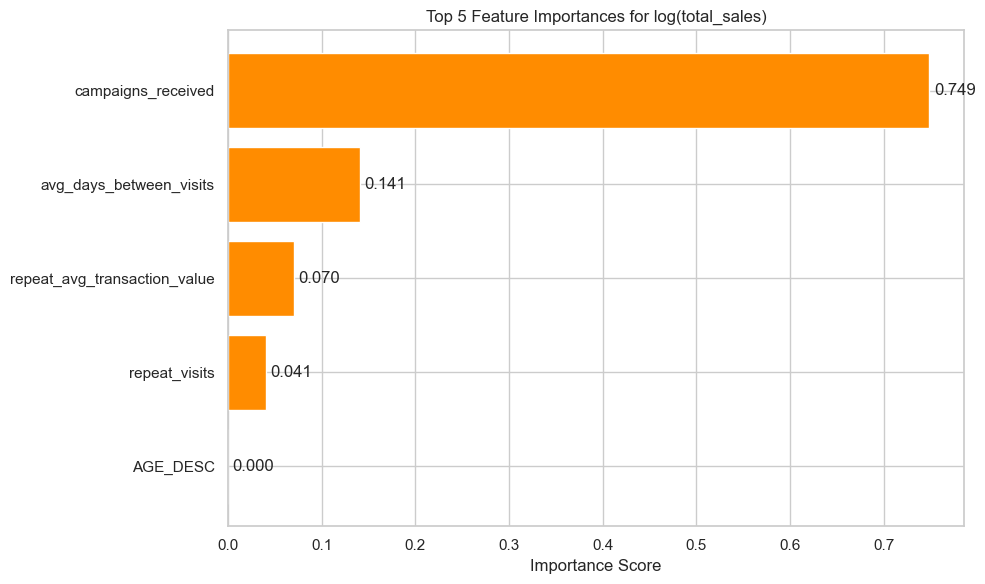

NameError: name 'top5_path' is not defined

In [152]:
# ----------------------------
# Feature Importance using df_merged
# ----------------------------
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder

# Ensure categorical encoding (repeat if needed)
df_model = df_merged.copy().dropna(subset=["total_sales"]).copy()

# Encode categorical variables if not already encoded
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Define features and target
X_merged = df_model.drop(columns=["household_key", "total_sales"])
y_merged = df_model["total_sales"]

# Fit tree for feature importance
tree_merged = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_merged.fit(X_merged, y_merged)

# ----------------------------
# Feature Importance Plot (Top 5)
# ----------------------------
importances = tree_merged.feature_importances_
feature_names = X_log.columns

# Select top 5 features
imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(5)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(imp_df["Feature"], imp_df["Importance"], color="darkorange")
plt.xlabel("Importance Score")
plt.title("Top 5 Feature Importances for log(total_sales)")
plt.gca().invert_yaxis()

# Annotate bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

plt.tight_layout()
top10_path = "C:/Users/sachi/Desktop/MSc Data Science/DSML/feature_importance_top5.png"
plt.savefig(top10_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"📂 Exported top 5 feature importance plot to {top5_path}")

# 4. ML: Creating Segments
#### Final run of decision trees to create binary tree with important features
##### After running multiple iterations, we limit our tree to a depth=3

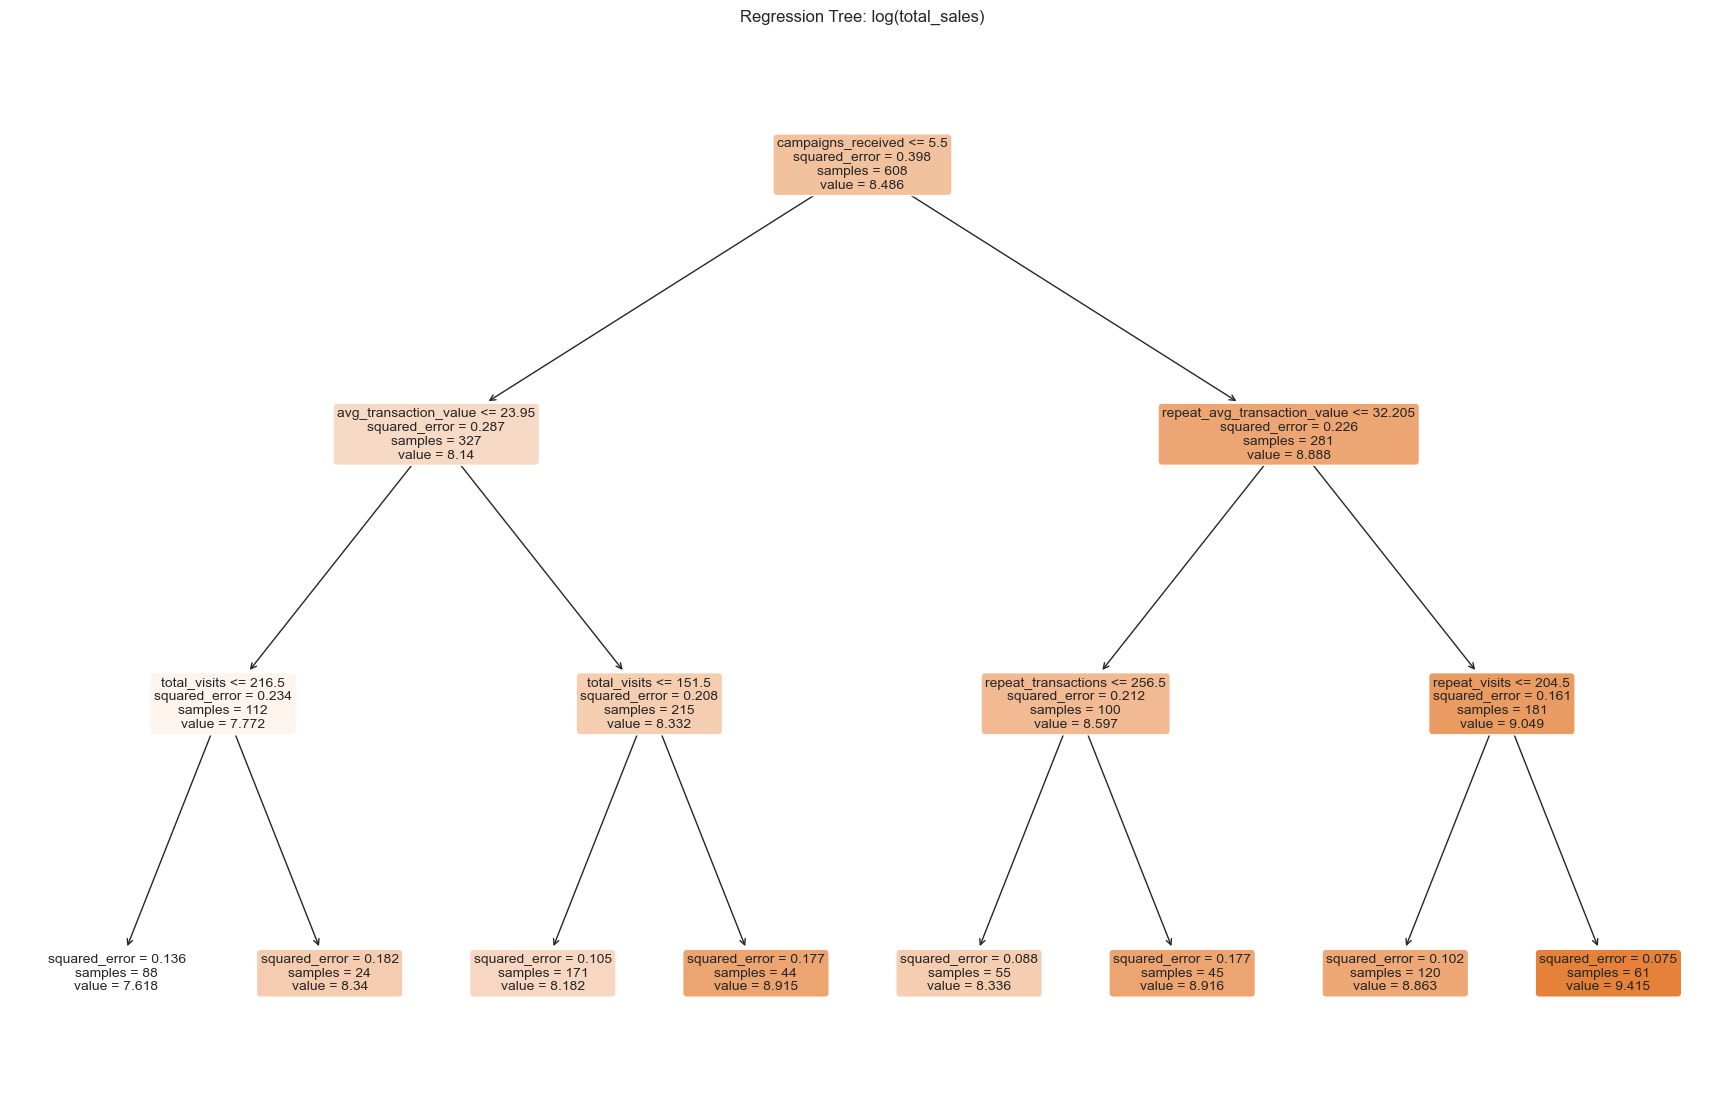

|--- campaigns_received <= 5.50
|   |--- avg_transaction_value <= 23.95
|   |   |--- total_visits <= 216.50
|   |   |   |--- value: [7.62]
|   |   |--- total_visits >  216.50
|   |   |   |--- value: [8.34]
|   |--- avg_transaction_value >  23.95
|   |   |--- total_visits <= 151.50
|   |   |   |--- value: [8.18]
|   |   |--- total_visits >  151.50
|   |   |   |--- value: [8.92]
|--- campaigns_received >  5.50
|   |--- repeat_avg_transaction_value <= 32.20
|   |   |--- repeat_transactions <= 256.50
|   |   |   |--- value: [8.34]
|   |   |--- repeat_transactions >  256.50
|   |   |   |--- value: [8.92]
|   |--- repeat_avg_transaction_value >  32.20
|   |   |--- repeat_visits <= 204.50
|   |   |   |--- value: [8.86]
|   |   |--- repeat_visits >  204.50
|   |   |   |--- value: [9.41]

📉 RMSE (log-scale): 0.3762
📈 R² Score        : 0.6017


C:\Users\sachi\AnacondaV2\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# ----------------------------
# Load cleaned dataset
# ----------------------------
df = pd.read_csv("C:/Users/sachi/Desktop/MSc Data Science/DSML/household_subset_for_modeling.csv")

# Drop rows with missing values
df_cleaned = df.dropna()

# Encode categorical features
categorical = ["AGE_DESC", "INCOME_DESC", "HOMEOWNER_DESC", 
               "MARITAL_STATUS_CODE", "HOUSEHOLD_SIZE_DESC", "KID_CATEGORY_DESC"]

df_cleaned = df_cleaned.copy()  # Avoid SettingWithCopyWarning
for col in categorical:
    df_cleaned.loc[:, col] = LabelEncoder().fit_transform(df_cleaned[col].astype(str))

# Log-transform target variable
df_cleaned["log_total_sales"] = np.log1p(df_cleaned["total_sales"])

# ----------------------------
# Define features and target
# ----------------------------
X_log = df_cleaned.drop(columns=["household_key", "total_sales", "log_total_sales"])
y_log = df_cleaned["log_total_sales"]

# Split data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# Train Decision Tree Regressor
log_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
log_tree.fit(X_train_log, y_train_log)

# ----------------------------
# Plot Tree (No Graphviz needed)
# ----------------------------
plt.figure(figsize=(22, 14))
plot_tree(
    log_tree,
    feature_names=X_log.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Regression Tree: log(total_sales)")
plt.show()

# ----------------------------
# Optional: Print tree rules
# ----------------------------
rules = export_text(log_tree, feature_names=list(X_log.columns))
print(rules)

# ----------------------------
# Evaluate on test set
# ----------------------------
y_pred_log = log_tree.predict(X_test_log)
rmse = mean_squared_error(y_test_log, y_pred_log, squared=False)
r2 = r2_score(y_test_log, y_pred_log)

print(f"📉 RMSE (log-scale): {rmse:.4f}")
print(f"📈 R² Score        : {r2:.4f}")


# 5. Evaluation

### 5.1 Plot predictions vs actuals

C:\Users\sachi\AnacondaV2\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



📈 Model Performance on Test Set
RMSE (in £): £2,042.38
R² Score     : 0.5559


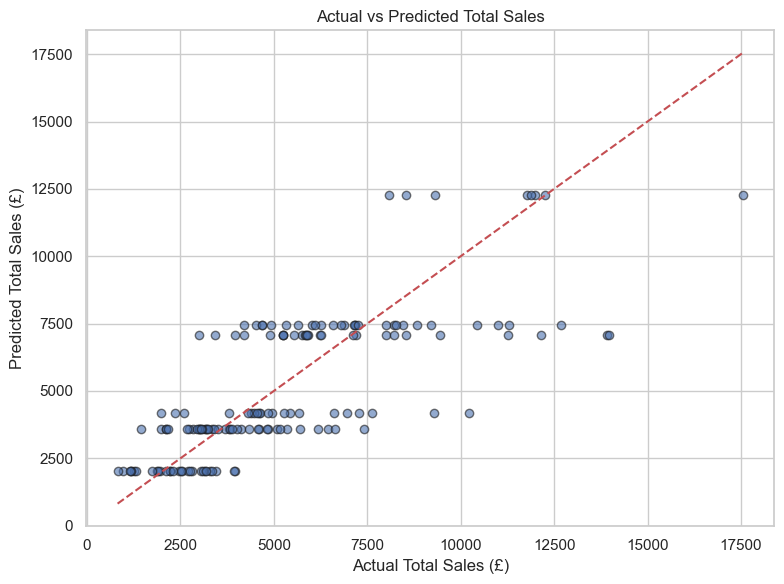

📂 Exported prediction comparison plot to C:/Users/sachi/Desktop/MSc Data Science/DSML/predicted_vs_actual_sales.png


In [201]:
# ----------------------------
# Evaluate model on test set
# ----------------------------
y_pred_log = log_tree.predict(X_test_log)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test_log)

rmse = mean_squared_error(y_actual, y_pred, squared=False)
r2 = r2_score(y_actual, y_pred)

print(f"\n\U0001F4C8 Model Performance on Test Set")
print(f"RMSE (in \u00a3): \u00a3{rmse:,.2f}")
print(f"R² Score     : {r2:.4f}")

# ----------------------------
# Plot predictions vs actuals
# ----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
plt.xlabel("Actual Total Sales (£)")
plt.ylabel("Predicted Total Sales (£)")
plt.title("Actual vs Predicted Total Sales")
plt.grid(True)
plt.tight_layout()

# Export to summary chart
summary_chart_path = "C:/Users/sachi/Desktop/MSc Data Science/DSML/predicted_vs_actual_sales.png"
plt.savefig(summary_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\U0001F4C2 Exported prediction comparison plot to {summary_chart_path}")


### 5.2 Residual Plot Distribution

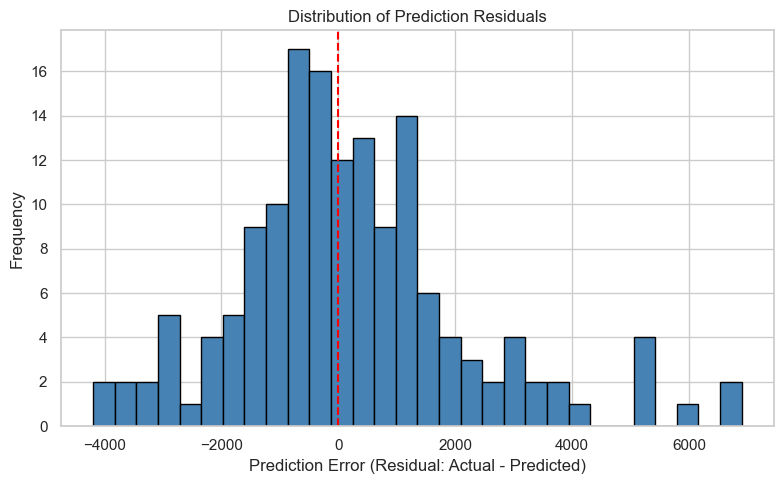

📁 Exported residual distribution plot to C:/Users/sachi/Desktop/MSc Data Science/DSML/residual_distribution.png


In [203]:
# ----------------------------
# Plot: Residual Distribution
# ----------------------------
residuals = y_actual - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black', color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Prediction Residuals")
plt.xlabel("Prediction Error (Residual: Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()

# Save and show
residual_path = "C:/Users/sachi/Desktop/MSc Data Science/DSML/residual_distribution.png"
plt.savefig(residual_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"📁 Exported residual distribution plot to {residual_path}")


### **5.3 Key insights from the Prediction error:** 
#### **Distribution shape :**

#### The residuals are roughly normally distributed, centered near zero.

#### This is a good sign — it suggests the model doesn’t systematically over or under-predict.

### **Bias check :**

#### The red dashed line at 0 marks perfect prediction.

#### Since the peak is slightly left of the red line, there may be a slight under-prediction bias for many households.

### **Spread and variability:**

#### The tails are longer on the right, indicating larger over-predictions are more common than large under-predictions.

### **Outliers:**

#### A few households have very large errors (±4000+), which could merit further investigation or exclusion if they’re anomalies.



### 5.4 Visually Assessment: Heteroscedasticity or Pattern bias 

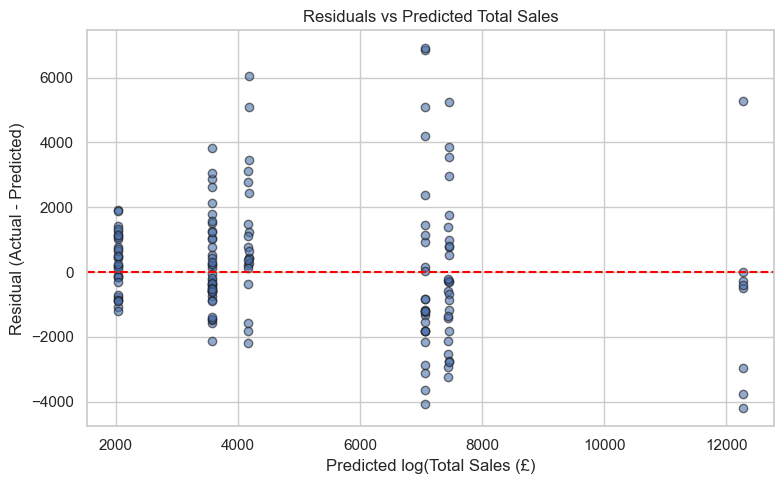

📂 Exported residuals vs predicted plot to C:/Users/sachi/Desktop/MSc Data Science/DSML/residuals_vs_predicted.png


In [205]:
# ----------------------------
# Plot: Residuals vs Predicted
# ----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='k')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted log(Total Sales (£)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Total Sales")
plt.grid(True)
plt.tight_layout()

residual_scatter_path = "C:/Users/sachi/Desktop/MSc Data Science/DSML/residuals_vs_predicted.png"
plt.savefig(residual_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\U0001F4C2 Exported residuals vs predicted plot to {residual_scatter_path}")


# 6. Results

# 7. Appendix